In [1]:
from chemflow.dataset.data_utils import get_mcs_atom_mapping

# Example: Phenol and Aniline (both share a benzene ring)
smi1 = "CCCC1=NN(C)C2=C1NC(=NC2=O)C3=C(OCC)C=CC(=C3)S(=O)(=O)N4CCN(C)CC4"
smi2 = "CCCC1=NC(=C2N1N=C(NC2=O)C3=C(OCC)C=CC(=C3)S(=O)(=O)N4CCN(CC)CC4)C"

mapping = get_mcs_atom_mapping(smi1, smi2)

print(f"SMILES 1: {smi1}")
print(f"SMILES 2: {smi2}")
print("Mapped Atom Indices (Mol1, Mol2):")
for idx1, idx2 in mapping:
    print(f"  Mol1 Atom {idx1} <--> Mol2 Atom {idx2}")

SMILES 1: CCCC1=NN(C)C2=C1NC(=NC2=O)C3=C(OCC)C=CC(=C3)S(=O)(=O)N4CCN(C)CC4
SMILES 2: CCCC1=NC(=C2N1N=C(NC2=O)C3=C(OCC)C=CC(=C3)S(=O)(=O)N4CCN(CC)CC4)C
Mapped Atom Indices (Mol1, Mol2):
  Mol1 Atom 1 <--> Mol2 Atom 33
  Mol1 Atom 2 <--> Mol2 Atom 5
  Mol1 Atom 3 <--> Mol2 Atom 6
  Mol1 Atom 4 <--> Mol2 Atom 7
  Mol1 Atom 5 <--> Mol2 Atom 8
  Mol1 Atom 8 <--> Mol2 Atom 11
  Mol1 Atom 9 <--> Mol2 Atom 10
  Mol1 Atom 10 <--> Mol2 Atom 9
  Mol1 Atom 14 <--> Mol2 Atom 13
  Mol1 Atom 15 <--> Mol2 Atom 14
  Mol1 Atom 16 <--> Mol2 Atom 15
  Mol1 Atom 17 <--> Mol2 Atom 16
  Mol1 Atom 18 <--> Mol2 Atom 17
  Mol1 Atom 46 <--> Mol2 Atom 44
  Mol1 Atom 47 <--> Mol2 Atom 45
  Mol1 Atom 48 <--> Mol2 Atom 46
  Mol1 Atom 44 <--> Mol2 Atom 42
  Mol1 Atom 45 <--> Mol2 Atom 43
  Mol1 Atom 19 <--> Mol2 Atom 18
  Mol1 Atom 20 <--> Mol2 Atom 19
  Mol1 Atom 21 <--> Mol2 Atom 20
  Mol1 Atom 22 <--> Mol2 Atom 21
  Mol1 Atom 51 <--> Mol2 Atom 49
  Mol1 Atom 23 <--> Mol2 Atom 22
  Mol1 Atom 24 <--> Mol2 Atom 23
  

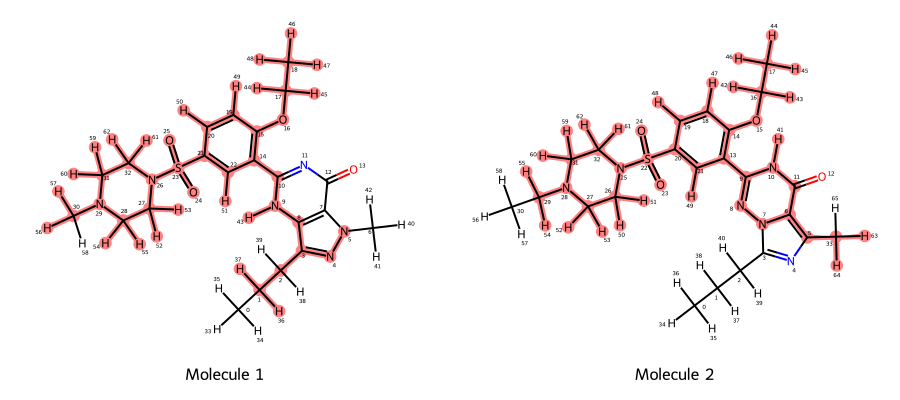

In [2]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display


def visualize_mapping(smiles1, smiles2, mapping):
    """
    Renders two molecules side-by-side in a Jupyter Notebook,
    highlighting the mapped atoms and displaying their indices.
    """
    mol1 = Chem.MolFromSmiles(smiles1)
    mol2 = Chem.MolFromSmiles(smiles2)

    mol1 = Chem.AddHs(mol1)
    mol2 = Chem.AddHs(mol2)

    # 1. Add atom index labels to the drawing for visual verification
    # Using 'atomNote' displays the number nicely next to the atom
    for atom in mol1.GetAtoms():
        atom.SetProp("atomNote", str(atom.GetIdx()))
    for atom in mol2.GetAtoms():
        atom.SetProp("atomNote", str(atom.GetIdx()))

    # 2. Extract the matched indices into separate lists for RDKit's highlighter
    mapped_atoms1 = [pair[0] for pair in mapping]
    mapped_atoms2 = [pair[1] for pair in mapping]

    # 3. Generate the side-by-side image
    img = Draw.MolsToGridImage(
        [mol1, mol2],
        molsPerRow=2,
        subImgSize=(450, 400),
        highlightAtomLists=[mapped_atoms1, mapped_atoms2],
        legends=["Molecule 1", "Molecule 2"],
        returnPNG=False,  # Returns a PIL Image which Jupyter natively displays
    )

    # 4. Display the image
    display(img)


visualize_mapping(smi1, smi2, mapping)

In [8]:
import torch
from rdkit import Chem
from rdkit.Chem import AllChem, rdFMCS
from rdkit.Geometry import Point3D

from chemflow.utils import rigid_alignment


def align_molecules(smiles0, smiles1, mapping):
    """
    Generates 3D structures for two SMILES and aligns mol2 onto mol1.
    """
    # 1. Create molecules and add Hydrogens
    mol0 = Chem.AddHs(Chem.MolFromSmiles(smiles0))
    mol1 = Chem.AddHs(Chem.MolFromSmiles(smiles1))

    # 2. Generate 3D conformations
    # Using a fixed random seed ensures reproducibility
    AllChem.EmbedMolecule(mol0, randomSeed=42)
    AllChem.EmbedMolecule(mol1, randomSeed=42)

    # 4. Extract 3D coordinates for the mapped atoms
    conf0 = mol0.GetConformer()
    conf1 = mol1.GetConformer()

    # Create tensors for the mapped subsets
    pts0 = torch.tensor(
        [list(conf0.GetAtomPosition(idx0)) for idx0, _ in mapping], dtype=torch.float32
    )
    pts1 = torch.tensor(
        [list(conf1.GetAtomPosition(idx1)) for _, idx1 in mapping], dtype=torch.float32
    )

    # 5. Calculate Kabsch alignment
    # Based on the math in your Kabsch function, mapping x_0 to x_1 requires
    # passing the mobile molecule (mol2) as x_0 and the target molecule (mol1) as x_1.
    R, t = rigid_alignment(x_0=pts0, x_1=pts1)

    # 6. Apply the transformation to ALL atoms in mol2
    all_pts1 = torch.tensor(
        [list(conf1.GetAtomPosition(i)) for i in range(mol1.GetNumAtoms())],
        dtype=torch.float32,
    )

    # Apply rotation and translation.
    # Because our coordinates are row vectors (N, 3), we multiply by R transposed.
    aligned_pts1 = all_pts1.mm(R.T) + t

    # 7. Update mol2 coordinates in the RDKit object
    for i in range(mol1.GetNumAtoms()):
        new_coords = aligned_pts1[i].tolist()
        conf1.SetAtomPosition(i, Point3D(*new_coords))

    return conf0, conf1


conf0, conf1 = align_molecules(smi1, smi2, mapping)


In [ ]:
import py3Dmol

width = 800
height = 400

mol_block = Chem.MolToMolBlock(mol)

# Visualize with py3Dmol
view = py3Dmol.view(width=width, height=height)
view.addModel(mol_block, "mol")
view.setStyle({"stick": {"radius": 0.15}, "sphere": {"scale": 0.2}})
view.zoomTo()
view.show()